# Exercise 1 — Linear Regression


## Part A: Understanding LR

Imagine we have data from a small restaurant.

For each table, we know:

- the total bill
- the tip left by the customer

We want to predict the tip from the bill using a straight line:

`predicted tip = weight × bill + bias`

Your task is to change `weight` and `bias` until the line fits the data as well as possible.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Sample restaurant data
# x = total bill in dollars
# y = tip in dollars

x = np.array([5, 7, 10, 12, 15, 17, 18, 20, 22, 25, 28, 30, 33, 35, 40, 45,50])

y = np.array([0.15, 0.5, 1.8, 2.0, 2.7, 2.8 ,3.0, 3.6, 3.5, 4.2, 4.8, 5.0, 2.5, 5.8, 6.5, 7.0,7.5])

In [59]:
# You should change only these two numbers
weight = 0.125

bias = 0.2


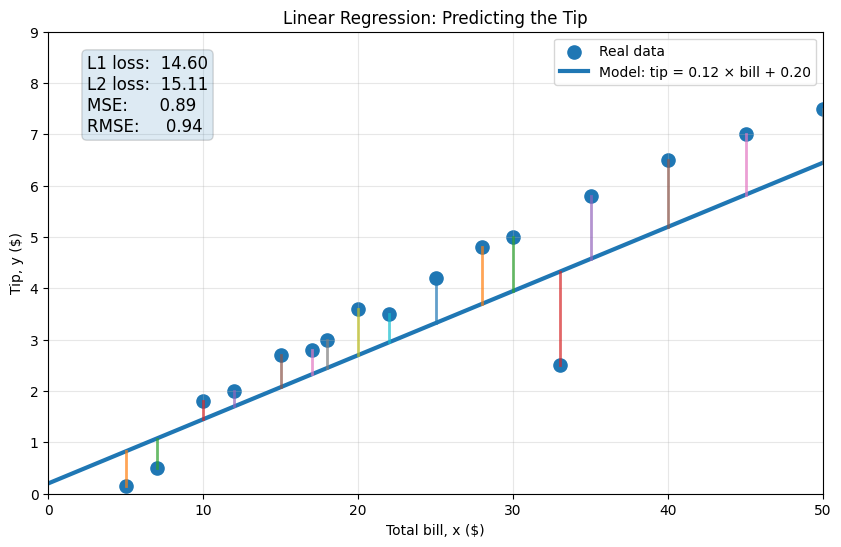

In [60]:
# Predictions
y_pred = weight * x + bias

# Residuals and losses
residuals = y - y_pred

l1 = np.sum(np.abs(residuals))
l2 = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=90, label="Real data")

# Regression line
x_line = np.linspace(0, 50, 100)
y_line = weight * x_line + bias

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label=f"Model: tip = {weight:.2f} × bill + {bias:.2f}"
)

# Residual lines
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=2, alpha=0.7)

plt.title("Linear Regression: Predicting the Tip")
plt.xlabel("Total bill, x ($)")
plt.ylabel("Tip, y ($)")

plt.xlim(0, 50)
plt.ylim(0, 9)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)

plt.text(
    0.05,
    0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.show()

### Your task

Change the values of `weight` and `bias`, then rerun the cell.

Try to make the line fit the points as well as possible.

Questions:

1. What is the lowest MSE you can find?
2. Which values of `weight` and `bias` gave you that MSE?
3. What happens to the residual lines when the model improves?
4. What does the `weight` mean in this example?
5. What does the `bias` mean?

### Answer
1, Lowest MSE: 0.74 \
2, weight: 0.125, bias: 0.2 \
3, When the model impproves, the residual lines get shoter and move closer to 0  \
4, The weight controls the angle of the line (It rotates the line around a pivot point) \
5, The bias controls the positions of the line along the y-axis (It slides the line up or down without changing its angle)

In [64]:
# Compute the best linear regression solution automatically

best_weight, best_bias = np.polyfit(x, y, 1)

y_best = best_weight * x + best_bias
best_mse = np.mean((y - y_best) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

Best weight: 0.154
Best bias:   0.315
Best MSE:    0.019
Best RMSE:   0.139


## Part B: Use a real dataset

In the previous exercise, we used (unexisting) sample data.

Now choose one real dataset and repeat the same process:

1. Load the dataset.
2. Choose one numerical column as `x`.
3. Choose one numerical column as `y`.
4. Fit a line manually by changing `weight` and `bias`.
5. Compute the residuals, MSE, and RMSE.
6. Compare your manual line with the best line found by Python.

The model is always:

`y_pred = weight * x + bias`

### Option 1 — Student performance dataset from Hugging Face

This one is probably closest to your idea:

> Can we predict exam score from study hours?

The Hugging Face dataset `krishal07/student-performance` includes columns such as `StudyHours`, `TestScore_Math`, `TestScore_Reading`, `TestScore_Science`, `GPA`, and `AttendanceRate`.  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("krishal07/student-performance", split="train")

df = dataset.to_pandas()
df.head()

data/train.csv:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

data/validation.csv:   0%|          | 0.00/166M [00:00<?, ?B/s]

data/test.csv:   0%|          | 0.00/166M [00:00<?, ?B/s]

In [ ]:
# Question:
# Can we predict math test score from study hours?

x = df["StudyHours"].to_numpy()
y = df["TestScore_Math"].to_numpy()

print("Number of students:", len(x))
print("First 5 study-hour values:", x[:5])
print("First 5 math scores:", y[:5])

#### Questions

1. Does more study time usually mean a higher test score?
2. Is the relationship perfectly linear?
3. Are there students with high study time but lower scores?
4. What other variables might help predict exam score?

### Option 2 — Bike rentals and weather

This is a good urban-mobility example:

> Can we predict bike rentals from temperature?

Use the UCI Bike Sharing Dataset. It contains bike rental counts together with weather and seasonal information. The official UCI page describes this as a bike-sharing dataset with hourly and daily rental counts plus weather/seasonal information.  

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import urllib.request

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"
zip_path = "Bike-Sharing-Dataset.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path) as z:
    with z.open("day.csv") as f:
        df = pd.read_csv(f)

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [68]:
# Question:
# Can we predict total daily bike rentals from temperature?

x = df["temp"].to_numpy()
y = df["cnt"].to_numpy()

print("Number of days:", len(x))
print("First 5 temperature values:", x[:5])
print("First 5 rental counts:", y[:5])

Number of days: 731
First 5 temperature values: [0.344167 0.363478 0.196364 0.2      0.226957]
First 5 rental counts: [ 985  801 1349 1562 1600]


#### Questions

1. Do warmer days usually have more bike rentals?
2. Is temperature enough to explain bike rentals?
3. Where are the residuals largest?
4. What other variables might help?

### Option 3 — Tips dataset

This is simple and easy to understand:

> Can we predict the tip from the total bill?

The `seaborn-data` repository provides sample datasets used in `seaborn` examples, including `tips.csv`.  

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Question:
# Can we predict the tip from the total bill?

x = df["total_bill"].to_numpy()
y = df["tip"].to_numpy()

print("Number of tables:", len(x))
print("First 5 bills:", x[:5])
print("First 5 tips:", y[:5])

#### Questions

1. Does a larger bill usually mean a larger tip?
2. What does the weight mean in this example?
3. Can one line explain all tipping behavior?
4. What other variables might help?

### Option 4 — Car fuel efficiency

This is useful because the relationship is negative:

> Can we predict fuel efficiency from car weight?

The `mpg.csv` dataset is also available in the `seaborn-data` repository.  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)
df = df.dropna()

#df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Number of cars: 392
First 5 weights: [3504. 3693. 3436. 3433. 3449.]
First 5 mpg values: [18. 15. 18. 16. 17.]
Best weight: -0.008
Best bias:   46.217
Best MSE:    18.677
Best RMSE:   4.322


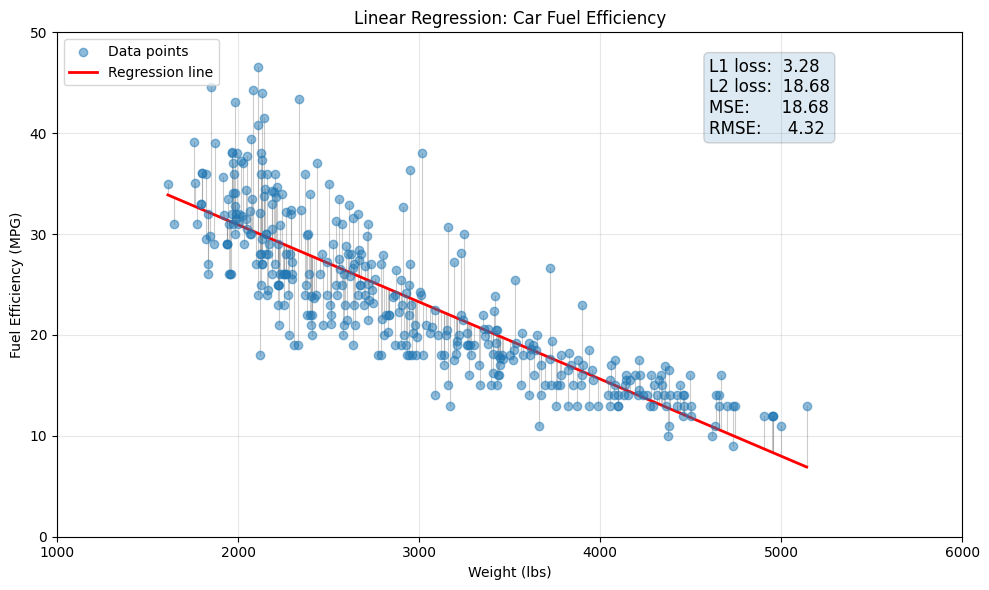

In [5]:
#----------------------------- Manually ------------------------------
# print("Number of cars:", len(x))
# print("First 5 weights:", x[:5])
# print("First 5 mpg values:", y[:5])


# m, b = np.polyfit(x, y, 1)
# y_pred = m * x + b


# l1  = np.mean(np.abs(y - y_pred))
# l2  = np.mean((y - y_pred) ** 2)
# mse = l2
# rmse = np.sqrt(mse)

# plt.figure(figsize=(10, 6))

# # Residual lines
# for xi, yi, ypi in zip(x, y, y_pred):
#     plt.plot([xi, xi], [yi, ypi], color="gray", linewidth=0.8, alpha=0.4)

# # Scatter plot + regression line
# plt.scatter(x, y, alpha=0.5, label="Data points", zorder=3)
# x_line = np.linspace(x.min(), x.max(), 200)
# plt.plot(x_line, m * x_line + b, color="red", linewidth=2, label="Regression line")

# plt.title("Linear Regression: Car Fuel Efficiency")
# plt.xlabel("Weight (lbs)")          
# plt.ylabel("Fuel Efficiency (MPG)") 

# plt.xlim(1000, 6000)  
# plt.ylim(0, 50)       
# plt.grid(True, alpha=0.3)
# plt.legend()        

# loss_text = (
#     f"L1 loss:  {l1:.2f}\n"
#     f"L2 loss:  {l2:.2f}\n"
#     f"MSE:      {mse:.2f}\n"
#     f"RMSE:     {rmse:.2f}"
# )

# plt.text(
#     0.72, 0.95,
#     loss_text,
#     transform=plt.gca().transAxes,
#     verticalalignment="top",
#     bbox=dict(boxstyle="round", alpha=0.15),
#     fontsize=12
# )

# plt.tight_layout()
# plt.show()


#--------------------- Automatically-----------------------#
print("Number of cars:", len(x))
print("First 5 weights:", x[:5])
print("First 5 mpg values:", y[:5])

best_weight, best_bias = np.polyfit(x, y, 1)
y_pred   = best_weight * x + best_bias
best_mse  = np.mean((y - y_pred) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

l1   = np.mean(np.abs(y - y_pred))
l2   = np.mean((y - y_pred) ** 2)
mse  = l2
rmse = np.sqrt(mse)

plt.figure(figsize=(10, 6))

for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], color="gray", linewidth=0.8, alpha=0.4)

plt.scatter(x, y, alpha=0.5, label="Data points", zorder=3)

x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, best_weight * x_line + best_bias,
         color="red", linewidth=2, label="Regression line")

plt.title("Linear Regression: Car Fuel Efficiency")
plt.xlabel("Weight (lbs)")
plt.ylabel("Fuel Efficiency (MPG)")
plt.xlim(1000, 6000)
plt.ylim(0, 50)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)
plt.text(
    0.72, 0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.tight_layout()
plt.show()

#### Questions

1. Do heavier cars usually have lower fuel efficiency?
2. Is the relationship perfectly linear?
3. What other variables might help predict fuel efficiency?

### Answer 
1, **Yes** - there is a clear negative correlation.
- The regression slope is negative (best_weight ≈ -0.0077), meaning for every 1,000 lbs of extra weight, MPG drops by roughly ~7.7 MPG
- Physically this makes sense: heavier cars require more energy (fuel) to accelerate and maintain speed
- The trend is consistent across the dataset (weight range ~1,600 – 5,200 lbs) \

2, **No** - it's approximately linear, but with clear limitations.

3, **Variables prediction:**
- More cylinders = more fuel burned per cycle.(↑ cylinders → ↓ MPG)
- More power output = more fuel consumed.(↑ horsepower → ↓ MPG)
- Larger engine volume burns more fuel. (↑ displacement → ↓ MPG)
- Newer cars are more fuel-efficient (regulations improved). (↑ year → ↑ MPG)
- Acceleration ~ MPG. Not influence significantly -> little impact

### Option 5 — Find another dataset!

If you prefer, look for another dataset that interests you.

Good places to search:

- [Hugging Face Datasets](https://huggingface.co/datasets)
- [Kaggle Datasets](https://www.kaggle.com/datasets)
- [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets)
- [Seaborn example datasets](https://github.com/mwaskom/seaborn-data)

Your dataset should have at least two numerical columns.

Use [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to train the model.

Choose:

- one numerical column as `x`
- one numerical column as `y`

Then ask a question like:

`Can we predict y from x?`

Examples:

- Can we predict exam score from study time?
- Can we predict bike rentals from temperature?
- Can we predict house price from size?
- Can we predict fuel efficiency from car weight?
- Can we predict product sales from advertising budget?

After choosing your dataset:

1. Load the dataset.
2. Display the first rows with `df.head()`.
3. Choose your `x` and `y` columns.
4. Plot the data.
5. Try to fit a line manually by changing `weight` and `bias`.
6. Compute the MSE and RMSE.
7. Compare your line with the best line found by Python.

Remember: not every dataset will work well with a straight line.  
That is part of the exercise.